# Image Dehazing - Dark Channel Prior
## Cristina Papi, Marco Rosato


# Atmospheric Scattering Model

Image degradation in foggy scenes is commonly described by the atmospheric scattering model, where the observed image is the sum of attenuated scene radiance and atmospheric light:

$I(x) = J(x)t(x) + A(1-t(x))$

$I(x)$ is the observed hazy image;

$J(x)$ the unknown clear image;

$t(x) \in (0,1]$ the transmission map;

$A$ the global atmospheric light.


---


Recovering $J(x)$ from $I(x)$ is an underdetermined problem, as both $J(x)$ and $t(x)$ are unknown.

# Dataset
The dataset we will use is the [Synthetic Objective Testing Set (SOTS) [RESIDE]](https://www.kaggle.com/datasets/balraj98/synthetic-objective-testing-set-sots-reside)
In particular, we will use the "Outside" part of the dataset.

# Installation, Libraries & Datase Load

In [1]:
!pip install opencv-contrib-python

In [2]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [3]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Dataset path
base_dir = "/content/drive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/Module 2/Outdoor"
hazy_dir = os.path.join(base_dir, "hazy")
clear_dir = os.path.join(base_dir, "clear")

print(f"Hazy Dir: {hazy_dir}")
print(f"Clear Dir: {clear_dir}")

Hazy Dir: /content/drive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/Module 2/Outdoor/hazy
Clear Dir: /content/drive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/Module 2/Outdoor/clear


In [5]:
def load_dataset_pairs(hazy_path, clear_path, num_images=492):
  """
  Loads a dataset of hazy and clear images.

  Arg:
    hazy_path: path to the folder containing the hazy images
    clear_path: path to the folder containing the clear images
    num_images: number of images to load (492 if not changed). Since we will not use use deep learning to train a model, we dont need a lot of data.

  Returns:
    loaded_hazy: list of hazy images
    loaded_clear: list of clear images
  """

  # The images pair have different name, but when they are sorted they match
  hazy_files  = sorted(f for f in os.listdir(hazy_path) if f.endswith(".jpg"))    # .jpg format for hazy images
  clear_files = sorted(f for f in os.listdir(clear_path) if f.endswith(".png"))   # .png format for clear images

  loaded_hazy = []
  loaded_clear = []

  for h, c in zip(hazy_files[:num_images], clear_files[:num_images]):     # read images "in parallel"

      # for each pair read, read images in BGR format and change to RGB with cv2.cvtColor
      img_h = cv2.imread(os.path.join(hazy_path, h))
      img_c = cv2.imread(os.path.join(clear_path, c))

      if img_h is None or img_c is None:
          continue

      loaded_hazy.append(cv2.cvtColor(img_h, cv2.COLOR_BGR2RGB))
      loaded_clear.append(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))

  print(f"Loaded {len(loaded_hazy)} pairs")
  return loaded_hazy, loaded_clear

# Load
hazy_imgs, clear_imgs = load_dataset_pairs(hazy_dir, clear_dir)

Loaded 492 pairs


In [6]:
# Visualization of our pairs

def visualize_comparison(hazy_list, clear_list, num_to_show=5):
    """
    Plots Hazy vs Clear images side by side.
    """
    plt.figure(figsize=(15, 5 * num_to_show))

    for i in range(num_to_show):
      # Plot cazy
      plt.subplot(num_to_show, 2, 2*i + 1)
      plt.imshow(hazy_list[i])
      plt.title(f"Input: Hazy Image {i+1}")
      plt.axis('off')

      # Plot clear (GT)
      plt.subplot(num_to_show, 2, 2*i + 2)
      plt.imshow(clear_list[i])
      plt.title(f"Ground Truth: Clear Image {i+1}")
      plt.axis('off')

plt.tight_layout()
plt.show()

# Visualization
visualize_comparison(hazy_imgs, clear_imgs, num_to_show=5)

Output hidden; open in https://colab.research.google.com to view.

# Dark Channel Prior (DCP)

The Dark Channel Prior, introduced by He et al. (2009), is based on the observation that in most haze-free outdoor images, local patches contain at least one color channel (R, G or B) with very low intensity. *For example*, in a green meadow, the red channel is almost zero. In a blue sky, the red channel is almost zero. In shadows, all three are almost zero.


Fog reduces this effect by increasing brightness in dark regions; therefore, the intensity of the dark channel provides a strong cue for haze density estimation.

## Get the dark channel

In a clear image (no haze), in any small patch, there is at least one pixel very dark (close to 0) in at least one color channel.

In an Haze image, however, the haze adds "whiteness" to the color channel making it white/grey.

To find the "dark channel", we will first find the lowest colour among every pixel, and then compare this values with the neighboor pixel to get the patch

$min\_channel(x)=min(R(x),G(x),B(x))$

$DarkChannel(x)=min(neighboorhood(x))$


---


The local window is used because the DCP is a statistical property of image patches, not individual pixels; it provides robustness to noise and texture while capturing the low-frequency nature of haze.

In [7]:
def dark_channel(image, window_size=15):
    """
    Computes the Dark Channel of an image.

    Args:
        image: input image (RGB)
        window_size: size of the local patch (15 as the original paper).

    Returns:
        dark_channel: 2D single-channel image representing the dark channel.
    """
    # Minimum value across the 3 color channels (R, G, B)
    min_channel = np.min(image, axis=2)

    # Creation of the patch:
    # "cv2.MORPH_RECT" -> we want the patch to be rectangular
    # "(window_size, window_size)" -> since the window_size is equal for both dimension, we will have a square patch
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (window_size, window_size))

    # "cv2.erode" find the minimum value across the local patch
    dark_channel = cv2.erode(min_channel, kernel)

    return dark_channel

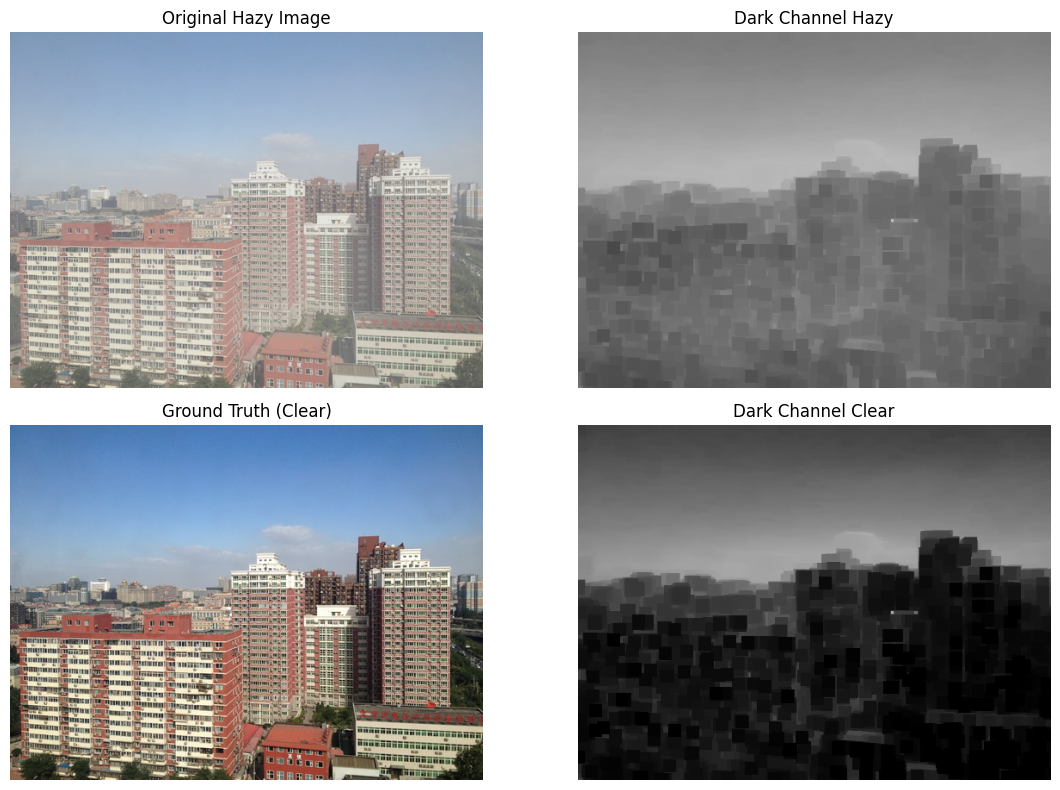

In [8]:
# First pair of images we loaded
sample_hazy = hazy_imgs[0]
sample_clear = clear_imgs[0]

# Compute Dark Channels
dc_hazy = dark_channel(sample_hazy, window_size=15)
dc_clear = dark_channel(sample_clear, window_size=15)





# PLOT
plt.figure(figsize=(12, 8))

# Row 1: hazy image and its dark channel
plt.subplot(2, 2, 1)
plt.imshow(sample_hazy)
plt.title("Original Hazy Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(dc_hazy, cmap='gray', vmin=0, vmax=255)   # to avoid matplot normalization (and a "bad" visualization) we set put the min value to 0 and the max to 255
plt.title("Dark Channel Hazy")
plt.axis('off')

# Row 2: clear image and its dark channel
plt.subplot(2, 2, 3)
plt.imshow(sample_clear)
plt.title("Ground Truth (Clear)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(dc_clear, cmap='gray', vmin=0, vmax=255)  # to avoid matplot normalization (and a "bad" visualization) we set put the min value to 0 and the max to 255
plt.title("Dark Channel Clear")
plt.axis('off')

plt.tight_layout()
plt.show()

We can notice that the in the top-right image (with haze), all our patches are grey. On the otherside, the bottom-right all the patches are black/darker

## Atmospheric Light Estimation $(A)$
This function estimates the Atmospheric Light $A$, which represents the intensity and color of the ambient illumination in the hazy scene. In an outside enviroment it is usually constant.

To ensure a robust estimation:



1.   Identify the **top 0.1% brightest pixels** in the previously computed Dark Channel, which represent the regions with the highest haze density.

2.   Within this candidate subset, we use the median value of the **intensity in the original RGB image**.

This dual-step approach ensures that the estimated value $A$ truly characterizes the ambient haze rather than local highlights or white surfaces in the clear regions of the image.





In [9]:
def atmospheric_light(image, dark_channel):
    """
    Estimates the Atmospheric Light (A) based on the Dark Channel.

    Args:
        image: original RGB hazy image.
        dark_channel: the dark channel computed previously.

    Returns:
        A: A numpy array of shape (3,) representing the RGB value of the atmospheric light.
    """
    # Extract height and width
    h, w = dark_channel.shape

    # Flatten for easier indexing
    flat_image = image.reshape((-1, 3))     # The original image is 3D (Height x Width x 3Colours) -> we get a 2D list where every row is exactly one pixel: [[R,G,B], [R,G,B], ...]
    flat_dark = dark_channel.ravel()        # The dark channel img is 2D since it is greyscaled -> we flatten it into a single line

    # Number of pixels in the top 0.1% of the image.
    # If the size is of 10000 pixels, we will take 10 pixels.
    num_pixels = flat_dark.size
    num_top_pixels = int(max(num_pixels * 0.001, 1))

    # Get the indices of the brightest pixels (so the ones with the highest value) in the Dark Channel
    # argpartition moves the highest elements to the end
    indices = np.argpartition(flat_dark, -num_top_pixels)[-num_top_pixels:]

    # Candidates from the original RGB image
    candidates = flat_image[indices]

    # Use the median pixel value across candidates
    A = np.median(candidates, axis=0).astype(np.uint8)

    return A

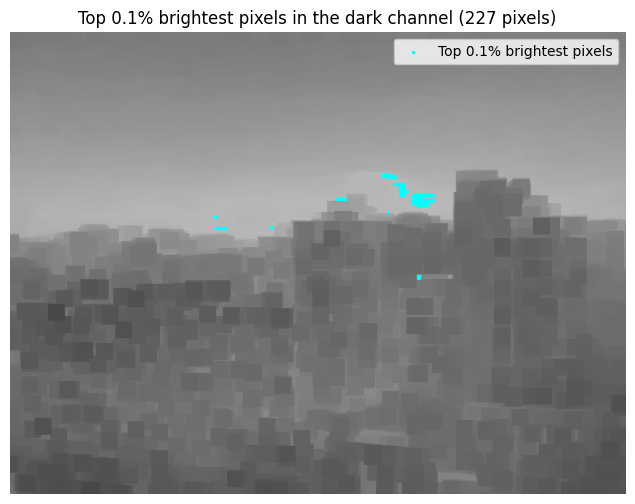

In [10]:
# Visualiazation of the top 0.1% bighter pixel in the Dark Channel image

flat_dark = dc_hazy.ravel()
num_top_pixels = int(max(flat_dark.size * 0.001, 1))
indices = np.argpartition(flat_dark, -num_top_pixels)[-num_top_pixels:]

# coordinates
y_coords, x_coords = np.unravel_index(indices, dc_hazy.shape)

# Visualization
plt.figure(figsize=(10, 6))
plt.imshow(dc_hazy, cmap='gray', vmin=0, vmax=255)
plt.scatter(x_coords, y_coords, c='cyan', s=2, label='Top 0.1% brightest pixels')
plt.title(f"Top 0.1% brightest pixels in the dark channel ({len(indices)} pixels)")
plt.legend(loc='upper right')
plt.axis('off')
plt.show()

Estimated Atmospheric Light (RGB): [189 194 202]


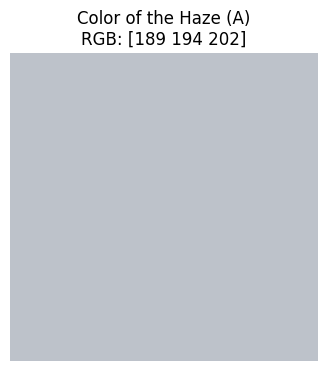

In [11]:
# Calculate A and its position the sample image

A_est = atmospheric_light(sample_hazy, dc_hazy)

print(f"Estimated Atmospheric Light (RGB): {A_est}")

# Colour visualization
color_block = np.zeros((100, 100, 3), dtype=np.uint8)
color_block[:] = A_est

plt.figure(figsize=(4, 4))
plt.imshow(color_block)
plt.title(f"Color of the Haze (A)\nRGB: {A_est}")
plt.axis('off')
plt.show()

## Transmission Map Estimation $t(x)$

The transmission map $t(x)$ acts as a **visibility factor**: it tells us how much of the original light from the objects actually "survives" the journey through the haze to reach the camera. Its value is directly linked to the distance (depth) of the objects (Beer-Lambert's Law):


*   $t(x)=1$ The object is very close $\rightarrow$ There is no haze in between, so we have full visibility;
*   $t(x)\approx 0$ The object is very far $\rightarrow$ The light is almost completely blocked by the haze, resulting in low visibility.

The transmission is estimated as:

$t(x)=1 -\omega\cdot DarkChannel(\frac{I(x)}{A})$

Where:

*   $A$ is the atmospheric light (the color of the haze).
*   $\omega \in (0,1]$, prevents the algorithm from removing 100% of the haze, ensuring the final image still looks natural and maintains a sense of depth.


In [12]:
def get_transmission(image, A, omega=0.92, window_size=15):
    """
    Estimates the raw transmission map.

    Args:
        image: hazy image (RGB).
        A: atmospheric light (RGB).
        omega: Parameter to keep a small amount of haze for depth perspective.
        window_size: Patch size for the dark channel.

    Returns:
        transmission: A 2D array (0 to 1) representing the transmission map.
    """
    # Normalize the image by the atmosphere light A -> (I(x)/A)
    # This "scales" the images based on the haze color.
    # - If a pixel's color is very similar to A (the haze), the normalized value will be close to 1.
    # - If a pixel represents a clear object (different from A), the value will be lower.
    norm_image = image.astype(np.float64) / (A.astype(np.float64) + 1e-6)    # add a small value do be sure to not dived by 0 (even if it is VERY improbable)

    # Calculate the Dark Channel of the normalized image -> DarkChannel(I(x)/A)
    # By searching for the minimum in a local patch:
    # - In hazy regions, even the minimum value remains high (close to 1) because haze is uniform.
    # - In clear regions, the Dark Channel Prior assumes the minimum will be close to 0 due to possible shadows or dark features of the objects.
    dc_norm = dark_channel(norm_image, window_size)

    # Apply the inversion formula: t(x) = 1 - omega * DarkChannel(I(x)/A)
    # - If dc_norm is high (~1), it means thick haze -> transmission t(x) becomes low (~0).
    # - If dc_norm is low (~0), it means clear sky/object -> transmission t(x) becomes high (~1).
    # The 'omega' parameter ensures we don't remove 100% of the haze, preserving a natural sense of depth.
    transmission = 1 - omega * dc_norm

    # Since DCP fails in bright and texturless regions (sky or clouds) -> luminance boundary constriant.
    # Pick the strongest colour and 0-1
    brightness = np.max(image, axis=2) / 255.0

    # If brightness > 0.7, we start PROTECTING the pixels from being over-dehazed
    # Below 0.7 -> normal dehaze
    # At 1.0 -> no dehaze
    protection = np.clip((brightness - 0.7) / (1.0 - 0.7), 0, 1)

    # - Dark area (protection = 0) -> normal DCP
    # - Mid-bright -> smooth DCP
    # - Very bright (protection = 1) -> no DCP
    transmission = (1.0 - protection) * transmission + (protection * 1.0)

    return transmission

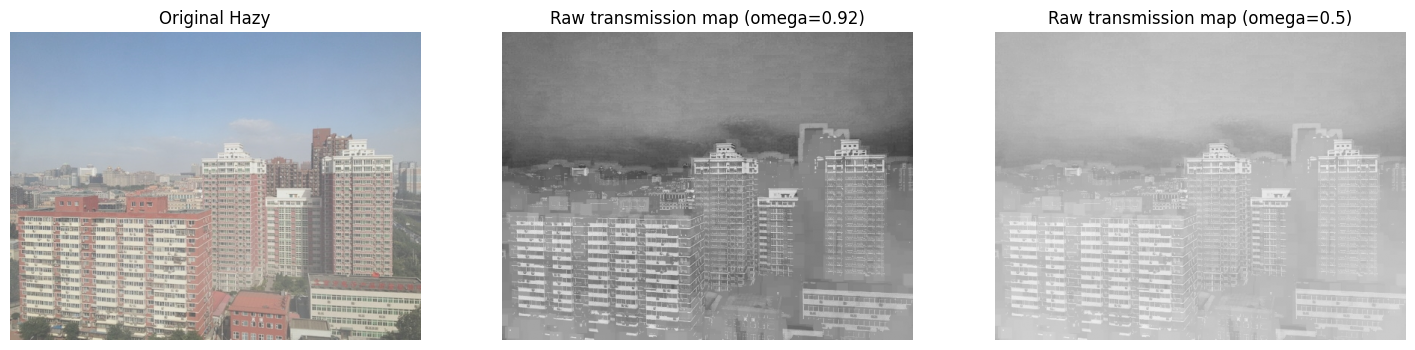

In [13]:
# Estimate Transmission with different omega values
transmission_raw = get_transmission(sample_hazy, A_est, omega=0.92, window_size=15)
transmission_05 = get_transmission(sample_hazy, A_est, omega=0.5, window_size=15)

# PLOT
plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)
plt.imshow(sample_hazy)
plt.title("Original Hazy")
plt.axis('off')

# omega = 0.95
plt.subplot(1, 3, 2)
plt.imshow(transmission_raw, cmap='gray', vmin=0, vmax=1)
plt.title("Raw transmission map (omega=0.92)")
plt.axis('off')

# omega = 0.5
plt.subplot(1, 3, 3)
plt.imshow(transmission_05, cmap='gray', vmin=0, vmax=1)
plt.title("Raw transmission map (omega=0.5)")
plt.axis('off')

plt.show()

To compute the transmission map, we use the same patch size used for the Dark Channel calculation.

*   $\omega =0.95$ (stronger removal): Lower transmission values ($t \rightarrow 0$) tell the algorithm that most of the light in those areas is haze, leading to a stronger restoration;
*   $\omega =0.5$ (lower removal): Higher transmission values ($t \rightarrow 1$) indicate that we are more conservative, preserving a larger fraction of the original haze.



## Guided Filtering
A guided filter is applied to refine the transmission map. Without this step, the previous patch-based estimation would introduce block artifacts and halo effects to the restored image. The filter will:

*   **Smooths** homogeneous regions of the transmission map
*   **Preserves sharp edges** by aligning them with intensity discontinuities in the original image

The guided filter will use the original hazy image as a "guide" to help the transmission map.



In [14]:
def refine_transmission(image, transmission_raw, r=60, eps=1e-4):
    """
    Transmission map with OpenCV's Guided Filter.

    Arg:
        image: original hazy image
        transmission_raw: raw transmission map
        r: radius of the window
        eps: regularization parameter
    Returns:
        transmission_refined: refined transmission map
    """

    # Create the guide image:
    # - Use gray scale like the transmission map
    # - Normalizse values between 0-1
    gray_guide = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_guide = (gray_guide / 255.0).astype(np.float32)

    # Transmission map
    transmission_raw = transmission_raw.astype(np.float32)

    # Guided Filter using OpenCV
    transmission_refined = cv2.ximgproc.guidedFilter(
        guide=gray_guide,           # Original gray scale image
        src=transmission_raw,       # Raw transmission map
        radius=r,                   # radius of the local windows -> depends on the dimension of the image
        eps=eps,                    # regularization parameter -> a lower value helps to preserve esges
        dDepth=-1
    )

    return transmission_refined

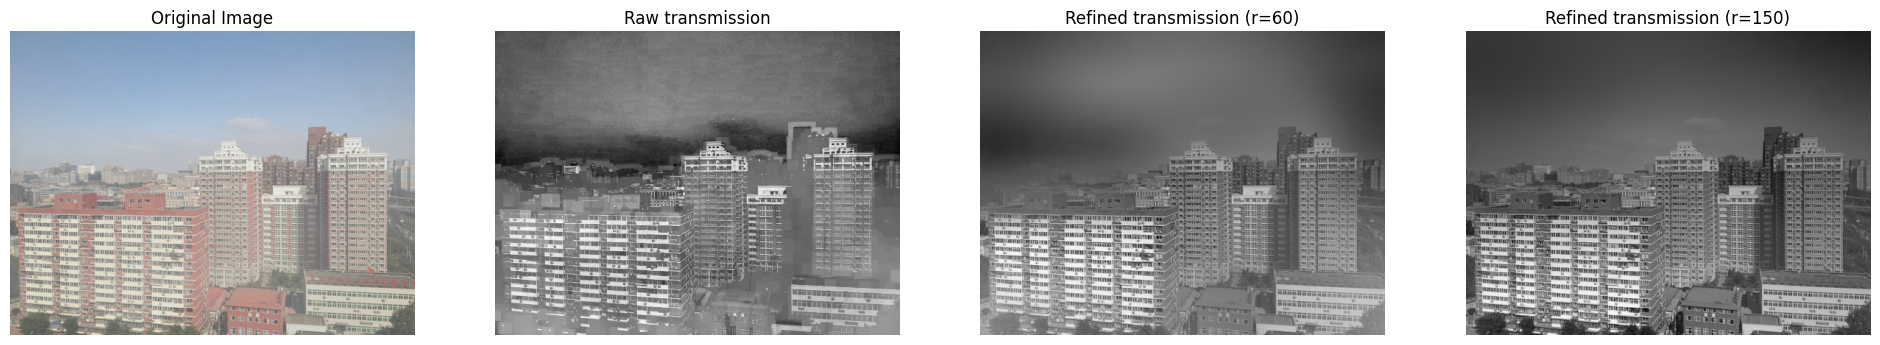

In [15]:
# Refined maps with different radii
transmission_refined_60 = refine_transmission(sample_hazy, transmission_raw, r=60, eps=1e-4)
transmission_refined_150 = refine_transmission(sample_hazy, transmission_raw, r=150, eps=1e-4)



# PLOT
plt.figure(figsize=(24, 6))

# Original hazy image
plt.subplot(1, 4, 1)
plt.imshow(sample_hazy)
plt.title("Original Image")
plt.axis('off')

# Raw transmission map
plt.subplot(1, 4, 2)
plt.imshow(transmission_raw, cmap='gray')
plt.title("Raw transmission")
plt.axis('off')

# Refined transmission (r=60)
plt.subplot(1, 4, 3)
plt.imshow(transmission_refined_60, cmap='gray')
plt.title("Refined transmission (r=60)")
plt.axis('off')

# Refined transmission (r=150)
plt.subplot(1, 4, 4)
plt.imshow(transmission_refined_150, cmap='gray')
plt.title("Refined transmission (r=150)")
plt.axis('off')

plt.show()

As we can see the image with the higher radius has an higher contrast leading to a sharper image, but, by keeping that parameter, there will be halos effect near he edges.

## Scene Recovery
Now we have all the part we need! We have the hazy image ($I$), the Atmosphere Light ($A$) and the refined Transmission map ($t$).

From the original equation:

$I(x) = J(x)t(x) + A(1-t(x))$

We can obtain:

$J(x)=\frac{I(x)-A}{t(x)}+A$

To prevent possible errors to the denominator $t(x)$, we will introduce a lower bound = 0.15:

$J(x)=\frac{I(x)-A}{max(t(x), t_0)}+A$

### Scale
Until now, we have worked with the parameters that where similar to the orginal paper. In reality, the choice of the windows and the radius depends on the dimension of the dimension of each single image.


In [16]:
def scale_params(image,
                 base_window=15,
                 base_width=600,
                 min_window=7,
                 max_window=101):
    """
    Computes scale-aware parameters based on image resolution.

    Args:
        image: input RGB image
        base_window: window size used for ~600px images
        base_width: reference width (SOTS Outdoor)
        min_window, max_window: min/top safety bounds

    Returns:
        window_size, guided_radius
    """
    # we get Height and Width from an image
    H, W = image.shape[:2]

    # Scale factor with respect to the reference resolution (600 pixel)
    # -> we use only the width since, in photography, the two dimension follow a proportion.
    scale = W / base_width

    # Dark channel window
    window_size = int(round(base_window * scale))
    window_size = max(min_window, min(window_size, max_window))
    if window_size % 2 == 0:
        window_size += 1  # force odd

    # Guided filter radius (4x the window)
    guided_radius = int(window_size * 4)

    return window_size, guided_radius

In [17]:
def recover_image(image, transmission, A, t0=0.15):
    """
    Recovers the scene radiance J from the hazy image I.
    """
    # Convert everything to float64 for precision
    img_float = image.astype(np.float64) / 255.0

    # Ensure A is the correct shape for broadcasting (1, 1, 3)
    A_float = np.array(A).astype(np.float64) / 255.0
    A_float = A_float.reshape(1, 1, 3)

    # Clip the transmission to avoid dividing by zero
    t_clipped = np.maximum(transmission, t0)

    # Expand transmission dims to (H, W, 1) to broadcast over 3 channels
    t_tiled = np.expand_dims(t_clipped, axis=2)

    # Apply the Formula: J = (I - A) / t + A
    J = (img_float - A_float) / t_tiled + A_float

    # Clip values to valid range [0, 1]
    J = np.clip(J, 0.0, 1.0)

    return J  # Returns float 0-1

### Gamma + Saturation correction
Since DCP produce dark images, we apply the gamma and saturation correction

In [18]:
def apply_stretching(image):
    # Min & Max value of the image
    img_min = image.min()
    img_max = image.max()

    # Stretching: (I - min) / (max - min)
    # Our values, after the stretching, will 0 for black and 1 for white
    stretched = (image - img_min) / (img_max - img_min + 1e-6)   # small constant to prevente 0 division
    return np.clip(stretched, 0, 1)

In [19]:
def final_enhancement(image, saturation_factor=1.05):
    # Stretching
    img_stretched = apply_stretching(image)

    # Gamma correction
    img_gamma = np.power(img_stretched, 1.0/1.1)

    # Change colour space to LAB
    img_uint8 = (img_gamma * 255).astype(np.uint8)
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Colour A & B saturation
    a_f = a.astype(np.float32)
    b_f = b.astype(np.float32)

    a_final = cv2.addWeighted(a_f, saturation_factor, np.full(a_f.shape, 128, np.float32), 1.0 - saturation_factor, 0)
    b_final = cv2.addWeighted(b_f, saturation_factor, np.full(b_f.shape, 128, np.float32), 1.0 - saturation_factor, 0)

    # Merge (using original L channel)
    limg = cv2.merge((l, a_final.astype(np.uint8), b_final.astype(np.uint8)))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    return final.astype(np.float64) / 255.0

### Pipeline + Visualization

In [20]:
def run_dehazing_pipeline(hazy_image, omega=0.92, t0=0.15, guide_eps=1e-4):
    """
    Runs the full DCP Dehazing pipeline.
    """
    # Get scale-aware parameters
    win_size, guide_r = scale_params(hazy_image)

    # Dark Channel
    dc = dark_channel(hazy_image, window_size=win_size)

    # Atmospheric Light (A)
    A = atmospheric_light(hazy_image, dc)

    # Transmission (Raw)
    t_raw = get_transmission(hazy_image, A, omega, window_size=win_size)

    # Transmission (Refined)
    t_refined = refine_transmission(hazy_image, t_raw, r=guide_r, eps=guide_eps)

    # Recovery (Raw Dehazing)
    J_recovered = recover_image(hazy_image, t_refined, A, t0=t0)

    # Enhancement (Gamma + Saturation)
    J_enhanced = final_enhancement(J_recovered)

    return J_recovered, J_enhanced, t_refined, A

In [21]:
# Select multiple image indices
target_indices = [0, 6, 15, 37, 145, 185, 294, 29, 167, 97, 222]

for idx in target_indices:
    hazy_img = hazy_imgs[idx]
    gt_img = clear_imgs[idx]

    # PIPELINE
    restored_raw, restored_enh, transmission, A_val = run_dehazing_pipeline(hazy_img)

    # PLOT
    plt.figure(figsize=(24, 6))

    # Original Hazy
    plt.subplot(1, 4, 1)
    plt.imshow(hazy_img)
    plt.title(f"Index {idx}: Input Hazy Image")
    plt.axis('off')

    # Dehazed ONLY
    plt.subplot(1, 4, 2)
    plt.imshow(restored_raw)
    plt.title("Dehazed (Raw Output)")
    plt.axis('off')

    # Dehazed + Enhancement
    plt.subplot(1, 4, 3)
    plt.imshow(restored_enh)
    plt.title("Dehazed + Enhancement (Gamma+Sat)")
    plt.axis('off')

    # Ground Truth
    plt.subplot(1, 4, 4)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Index {idx} - Estimated Atmospheric Light: {A_val}\n" + "-"*50)

Output hidden; open in https://colab.research.google.com to view.

# Metrics


In [22]:
def calculate_metrics(img_gt, img_processed):
    """
    Calculates PSNR and SSIM between a ground truth image and a processed image.

    Args:
        img_gt: Ground Truth Clear Image.
        img_processed: Processed Image.

    Returns:
        dictionary: PSNR and SSIM values.
    """
    # Ensure images are in the same range (0-1 float) -> metrics depends on data range
    if img_gt.max() > 1.0:
        img_gt = img_gt.astype(np.float64) / 255.0
    if img_processed.max() > 1.0:
        img_processed = img_processed.astype(np.float64) / 255.0

    # Calculate PSNR (data_range=1.0 because our images are now 0 to 1)
    p_val = psnr(img_gt, img_processed, data_range=1.0)

    # Calculate SSIM (channel_axis=2 because images are RGB (3 channels))
    s_val = ssim(img_gt, img_processed, data_range=1.0, channel_axis=2)

    return {"psnr": p_val, "ssim": s_val}


In [23]:
# Lists to store metrics for all images
results = {
    "initial": {"psnr": [], "ssim": []},
    "recovered": {"psnr": [], "ssim": []},
    "enhanced": {"psnr": [], "ssim": []}
}


for h_img, c_img in zip(hazy_imgs, clear_imgs):
    # Run the pipeline
    J_rec, J_enh, _, _ = run_dehazing_pipeline(h_img)

    # Calculate metrics
    m_init = calculate_metrics(c_img, h_img)
    m_rec  = calculate_metrics(c_img, J_rec)
    m_enh  = calculate_metrics(c_img, J_enh)

    # Store results
    results["initial"]["psnr"].append(m_init['psnr'])
    results["initial"]["ssim"].append(m_init['ssim'])
    results["recovered"]["psnr"].append(m_rec['psnr'])
    results["recovered"]["ssim"].append(m_rec['ssim'])
    results["enhanced"]["psnr"].append(m_enh['psnr'])
    results["enhanced"]["ssim"].append(m_enh['ssim'])

# Average table results
print("="*43)
print(f"{'AVERAGE':<20} | {'PSNR (dB)':<10} | {'SSIM':<10}")
print("-" * 43)
print(f"{'Hazy (Input)':<20} | {np.mean(results['initial']['psnr']):<10.2f} | {np.mean(results['initial']['ssim']):<10.4f}")
print(f"{'DCP Recovered':<20} | {np.mean(results['recovered']['psnr']):<10.2f} | {np.mean(results['recovered']['ssim']):<10.4f}")
print(f"{'DCP + Enhancement':<20} | {np.mean(results['enhanced']['psnr']):<10.2f} | {np.mean(results['enhanced']['ssim']):<10.4f}")
print("="*43)


AVERAGE              | PSNR (dB)  | SSIM      
-------------------------------------------
Hazy (Input)         | 15.97      | 0.8151    
DCP Recovered        | 22.95      | 0.9266    
DCP + Enhancement    | 23.81      | 0.9266    
